In [ ]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *
from joblib import Parallel, delayed
from matplotlib.pyplot import imshow
import warnings
warnings.filterwarnings("ignore")
from scipy.optimize import curve_fit
import equilibrium_critical_correlations as eq
from numpy import gradient as grad
from scipy.optimize import curve_fit



In [101]:
gs = np.linspace(.01,1,20)
L = 200
k = kb.k_vals(L)
Us = [kb.U(k,gi) for gi in gs]


In [102]:
P = []
ns = np.arange(1,13+1)

for U in tqdm(Us):
    Pg = [kb.P_n(ni,U,k) for ni in ns]
    P.append(Pg)

100%|██████████| 20/20 [01:13<00:00,  3.67s/it]


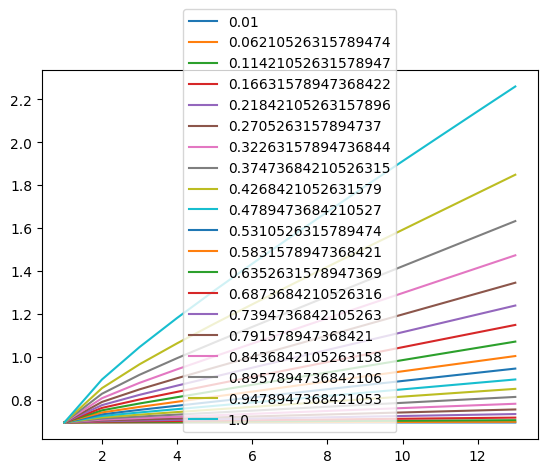

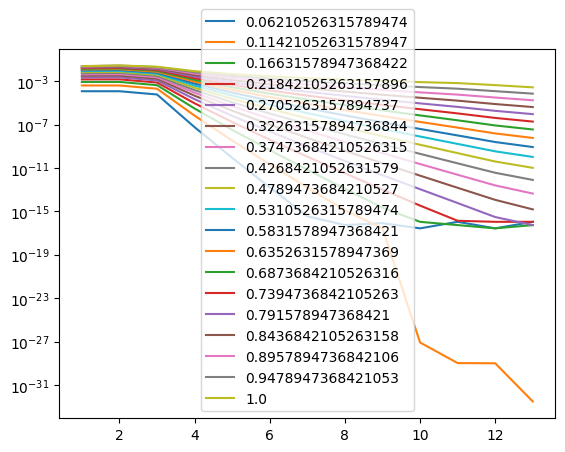

In [103]:
for p,g in zip(P,gs):
    plot(ns,-log(p),label=g)
legend()
show()
for p,g in zip(P[1:],gs[1:]):
    plot(ns,abs(grad(grad(-log(p),ns),ns)),label=g)
legend()
yscale("log")
show()

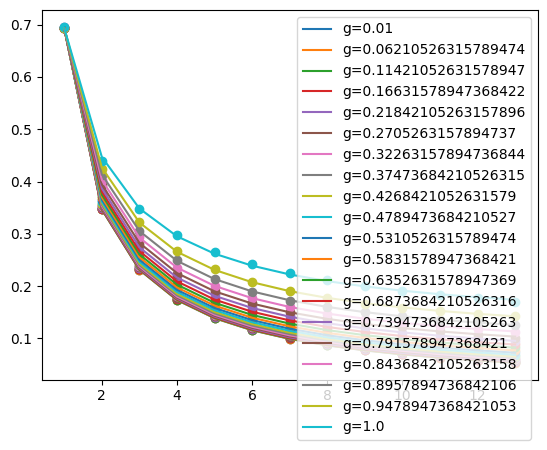

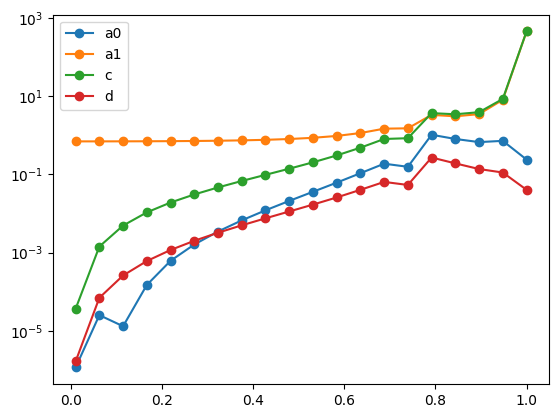

In [124]:
def model(x, a0, a1, c, d, g):
    xi = 1.0 / np.abs(1.0 - g)
    return a0 + a1/x + c*np.exp(-x/xi)/x + d*np.log(x)

dat = []
errs = []

for p, g in zip(P, gs):
    popt, pcov = curve_fit(
        lambda x, a0, a1, c, d: model(x, a0, a1, c, d, g),
        ns,
        -np.log(p)/ns
    )
    plt.plot(ns, -np.log(p)/ns, label=f"g={g}")
    plt.scatter(ns, model(ns, *popt, g))
    errs.append(np.sqrt(np.diag(pcov)))
    dat.append(popt)

plt.legend()
plt.show()

dat = np.array(dat)
errs = np.array(errs)
plt.figure()
plt.plot(gs, np.abs(dat[:,0]), 'o-', label="a0")
plt.plot(gs, np.abs(dat[:,1]), 'o-', label="a1")
plt.plot(gs, np.abs(dat[:,2]), 'o-', label="c")
plt.plot(gs, np.abs(dat[:,3]), 'o-', label="d")
yscale("log")
plt.legend()
plt.show()


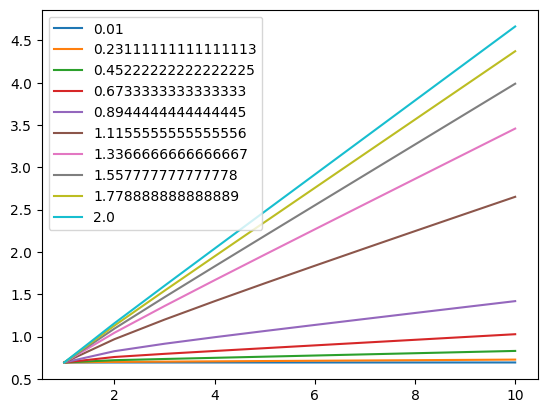